In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score

In [2]:
df = pd.read_csv('Student_Performance.csv')

In [3]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [4]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [5]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [7]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

### Step 1:- Correlation and scatter plots

In [8]:
df.select_dtypes(include='number').corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


### Prediceted conclusion 
* we have a very strong correlation between the feature column Previous score and target column named Performance Index
* so we may get the over all model performace in between the 85% to 95%

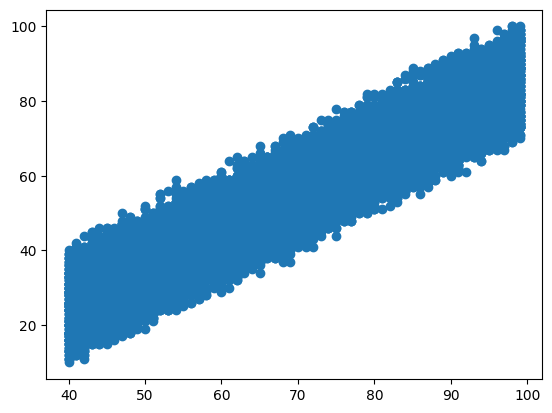

In [9]:
plt.scatter(df['Previous Scores'], df['Performance Index'])

Step 2:- Segrating X and y

In [10]:
x = df.drop(['Performance Index','Extracurricular Activities'], axis=1)
y = df['Performance Index']

In [11]:
x

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
0,7,99,9,1
1,4,82,4,2
2,8,51,7,2
3,5,52,5,2
4,7,75,8,5
...,...,...,...,...
9995,1,49,4,2
9996,7,64,8,5
9997,6,83,8,5
9998,9,97,7,0


In [12]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [13]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

In [14]:
xtrain

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
9254,5,49,7,5
1561,2,48,7,6
1670,2,81,7,2
6087,2,46,6,1
6669,8,47,9,0
...,...,...,...,...
5734,8,50,6,6
5191,4,68,9,3
5390,9,48,7,6
860,1,47,9,0


In [15]:
xtest

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
6252,5,69,8,2
4684,2,46,4,8
1731,7,56,7,5
4742,6,42,8,5
4521,7,53,4,6
...,...,...,...,...
6412,2,70,7,3
8285,4,79,9,3
7853,2,40,7,2
1095,3,83,7,5


In [16]:
ytrain

9254    36.0
1561    25.0
1670    59.0
6087    22.0
6669    40.0
        ... 
5734    48.0
5191    51.0
5390    44.0
860     20.0
7270    24.0
Name: Performance Index, Length: 8000, dtype: float64

In [17]:
ytest

6252    51.0
4684    20.0
1731    46.0
4742    28.0
4521    41.0
        ... 
6412    45.0
8285    66.0
7853    16.0
1095    65.0
6929    47.0
Name: Performance Index, Length: 2000, dtype: float64

Model Creation

In [18]:
model = LinearRegression()

Training the Model

In [19]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
model.predict(xtrain)

array([34.76901001, 25.38502005, 58.18029349, ..., 45.35527464,
       21.31136972, 22.8776303 ], shape=(8000,))

In [21]:
slope = model.coef_
slope

array([2.85289351, 1.01703572, 0.47331832, 0.19172629])

In [22]:
intercept = model.intercept_
intercept

np.float64(-33.60206732749263)

In [23]:
y_pred_train = model.predict(xtrain)

In [24]:
y_pred_test = model.predict(xtest)

In [25]:
ytrain - y_pred_train

9254    1.230990
1561   -0.385020
1670    0.819707
6087    0.081001
6669   -1.281624
          ...   
5734    3.936866
5191   -0.802979
5390   -1.355275
860    -1.311370
7270    1.122370
Name: Performance Index, Length: 8000, dtype: float64

In [26]:
ytest - y_pred_test

6252   -4.007864
4684   -2.314446
1731   -1.594047
4742   -2.975972
4521   -2.314711
          ...   
6412   -2.184627
8285    3.009628
7853   -0.481829
1095    1.357563
6929    0.762005
Name: Performance Index, Length: 2000, dtype: float64

### R**2 Score on the training data

In [27]:
r2_score(ytrain,y_pred_train)

0.9884388348325367

### R**2 Score on the testing data

In [28]:
r2_score(ytest,y_pred_test)

0.9887144552384186

### root_mean_squared_error for train data

In [29]:
root_mean_squared_error(ytrain,y_pred_train)

2.064531199312962

### root_mean_squared_error for test data

In [30]:
root_mean_squared_error(ytest,y_pred_test)

2.0450562130645253

Calculating Mean Absolute Error for train data

In [31]:
mean_absolute_error(ytrain,y_pred_train)

1.6398241480954336

In [32]:
mean_absolute_error(ytest,y_pred_test)

1.629672687419703

In [33]:
# plt.scatter(ytrain,y_pred_train)